In [ ]:
# Pin NumPy to 1.x so older compiled modules (and mixed conda/pip stacks) do not crash on NumPy 2.
# Then Kernel → Restart. Use a fresh conda env if warnings about ~andas or conflicts persist.
%pip install matplotlib seaborn scikit-learn "numpy<2" pandas

# Student Performance Analysis & Prediction

## Task 1 — Data Exploration with Pandas (5 marks)

Dataset: `students.csv` (15 students). Target column: `passed` (1 = Pass, 0 = Fail).

In [1]:
import pandas as pd

df = pd.read_csv("students.csv")

print("First 5 rows:")
print(df.head())
print()

print("Shape (rows × columns):", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print()

print("Summary statistics (numeric columns):")
print(df.describe())
print()

print("Pass / fail counts:")
print(df["passed"].value_counts())
print()

subject_cols = ["math", "science", "english", "history", "pe"]

print("Average score per subject — passing students (passed == 1):")
print(df[df["passed"] == 1][subject_cols].mean())
print()
print("Average score per subject — failing students (passed == 0):")
print(df[df["passed"] == 0][subject_cols].mean())
print()

overall_avg = df[subject_cols].mean(axis=1)
best_idx = overall_avg.idxmax()
best_name = df.loc[best_idx, "name"]
best_val = overall_avg.loc[best_idx]
print(
    f"Student with highest overall average (5 subjects): {best_name} ({best_val:.2f})"
)

/Users/shekharchatterjee/miniconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape (rows × columns): (15, 9)

Column dtypes:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary statistics (numeric columns):
    

## Task 2 — Data Visualization with Matplotlib (8 marks)

Add `avg_score`, then create five plots (titles, axis labels, legends where needed). Save each as a `.png` and show inline.

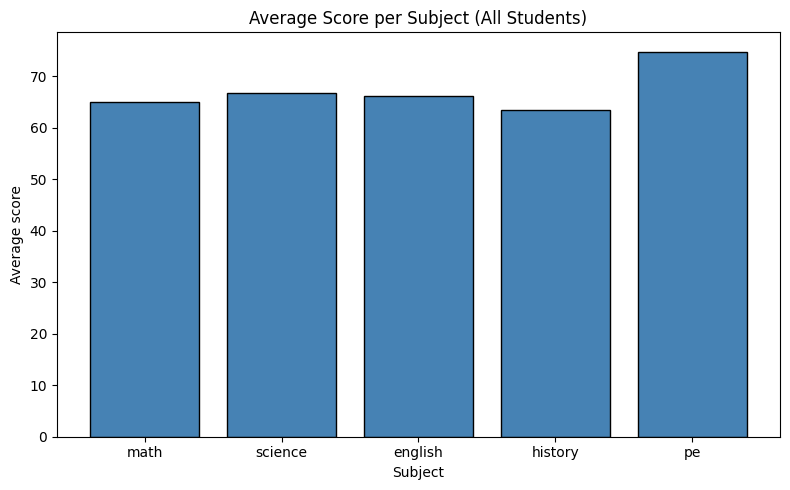

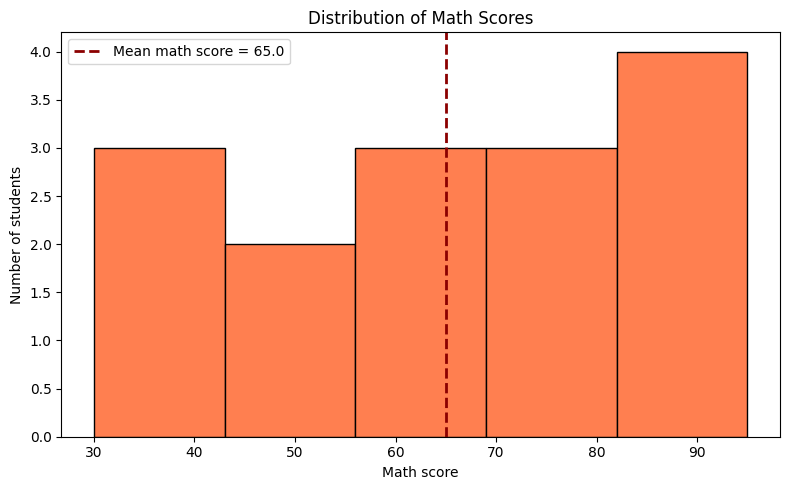

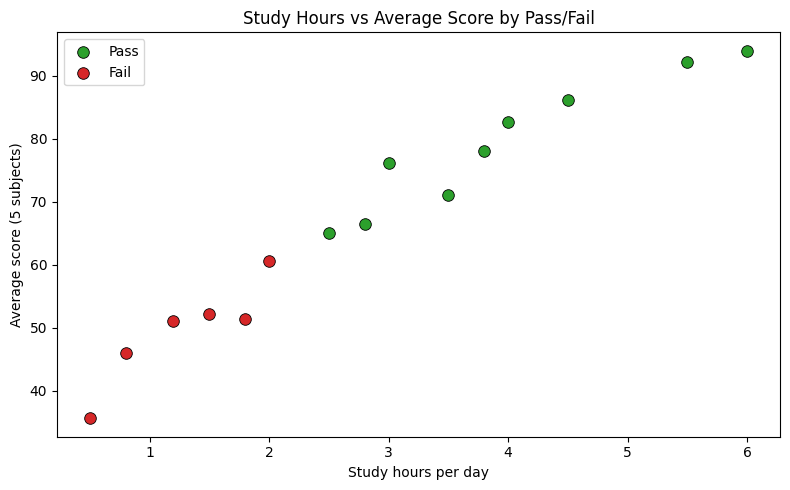

<ipython-input-2-876df21ce01c>:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])


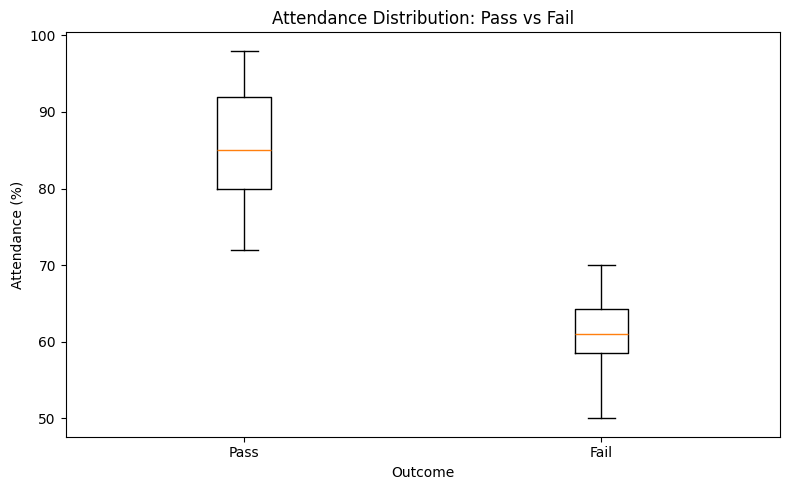

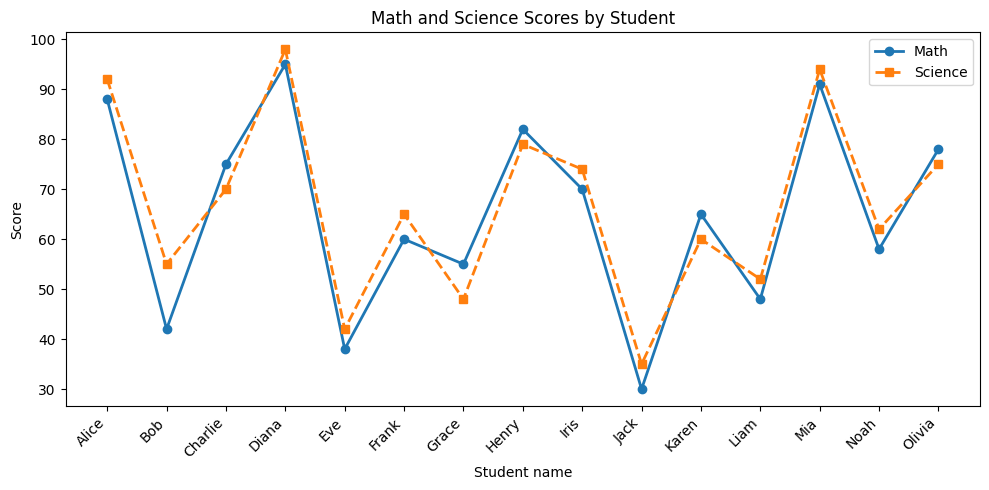

In [2]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("students.csv")
subject_cols = ["math", "science", "english", "history", "pe"]
df["avg_score"] = df[subject_cols].mean(axis=1)

# --- Plot 1: Bar chart — average score per subject (all students) ---
subject_means = df[subject_cols].mean()
fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(subject_means.index.astype(str), subject_means.values, color="steelblue", edgecolor="black")
ax1.set_xlabel("Subject")
ax1.set_ylabel("Average score")
ax1.set_title("Average Score per Subject (All Students)")
plt.tight_layout()
fig1.savefig("plot1_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Plot 2: Histogram — math scores (5 bins) + mean line ---
mean_math = df["math"].mean()
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.hist(df["math"], bins=5, color="coral", edgecolor="black")
ax2.axvline(mean_math, color="darkred", linestyle="--", linewidth=2, label=f"Mean math score = {mean_math:.1f}")
ax2.set_xlabel("Math score")
ax2.set_ylabel("Number of students")
ax2.set_title("Distribution of Math Scores")
ax2.legend()
plt.tight_layout()
fig2.savefig("plot2_hist.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Plot 3: Scatter — study hours vs avg_score, colour by passed ---
passed_1 = df[df["passed"] == 1]
passed_0 = df[df["passed"] == 0]
fig3, ax3 = plt.subplots(figsize=(8, 5))
ax3.scatter(
    passed_1["study_hours_per_day"],
    passed_1["avg_score"],
    c="tab:green",
    s=70,
    edgecolors="black",
    linewidths=0.6,
    label="Pass",
)
ax3.scatter(
    passed_0["study_hours_per_day"],
    passed_0["avg_score"],
    c="tab:red",
    s=70,
    edgecolors="black",
    linewidths=0.6,
    label="Fail",
)
ax3.set_xlabel("Study hours per day")
ax3.set_ylabel("Average score (5 subjects)")
ax3.set_title("Study Hours vs Average Score by Pass/Fail")
ax3.legend()
plt.tight_layout()
fig3.savefig("plot3_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Plot 4: Box plot — attendance: Pass vs Fail ---
pass_attendance = df[df["passed"] == 1]["attendance_pct"].tolist()
fail_attendance = df[df["passed"] == 0]["attendance_pct"].tolist()
fig4, ax4 = plt.subplots(figsize=(8, 5))
ax4.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])
ax4.set_ylabel("Attendance (%)")
ax4.set_xlabel("Outcome")
ax4.set_title("Attendance Distribution: Pass vs Fail")
plt.tight_layout()
fig4.savefig("plot4_box.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Plot 5: Line plot — math & science by student ---
fig5, ax5 = plt.subplots(figsize=(10, 5))
ax5.plot(df["name"], df["math"], marker="o", linestyle="-", linewidth=2, label="Math")
ax5.plot(df["name"], df["science"], marker="s", linestyle="--", linewidth=2, label="Science")
ax5.set_xlabel("Student name")
ax5.set_ylabel("Score")
ax5.set_title("Math and Science Scores by Student")
ax5.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig5.savefig("plot5_line.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 3 — Data Visualization with Seaborn (4 marks)

Grouped bar plots (math and science by pass or fail) and a scatter with regression lines per group. Save as PNG files.

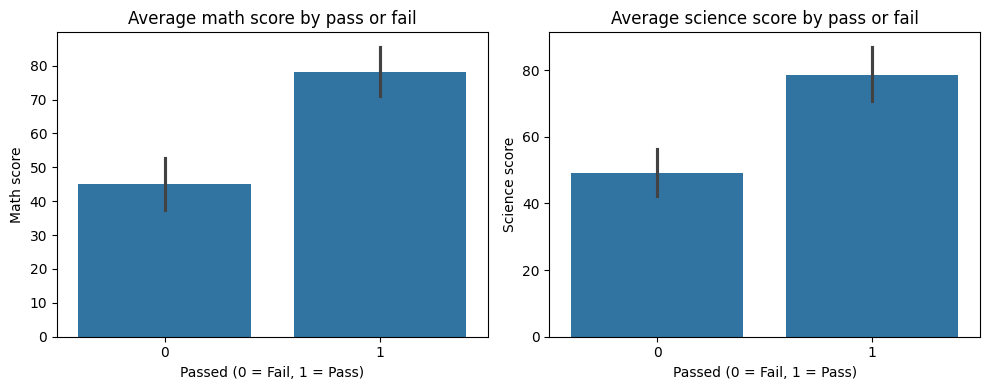

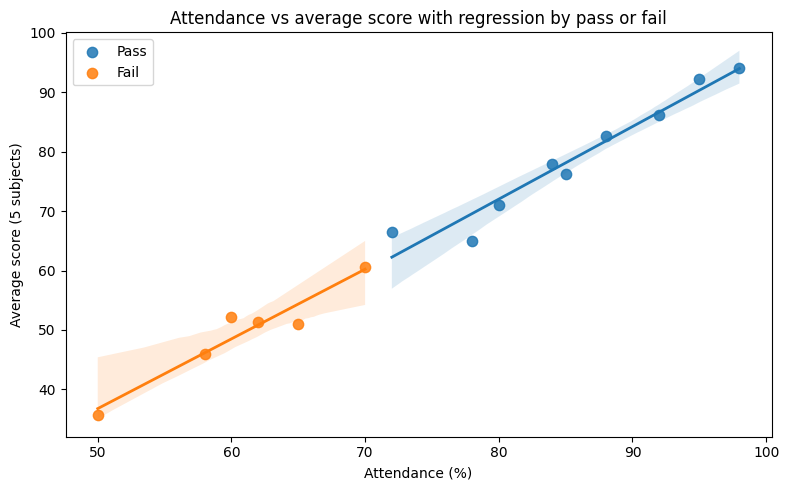

In [3]:
# Seaborn made bar means and regression lines feel faster than building the same plots
# only in Matplotlib, where I would split groups and compute averages by hand more often.
# I still used plt.subplots and savefig for layout and export, so the two libraries work
# best together rather than one fully replacing the other.

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("students.csv")
subject_cols = ["math", "science", "english", "history", "pe"]
df["avg_score"] = df[subject_cols].mean(axis=1)

# --- Seaborn bar plots: math and science means by passed (two subplots) ---
fig_bar, (ax_math, ax_sci) = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(data=df, x="passed", y="math", ax=ax_math)
ax_math.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax_math.set_ylabel("Math score")
ax_math.set_title("Average math score by pass or fail")

sns.barplot(data=df, x="passed", y="science", ax=ax_sci)
ax_sci.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax_sci.set_ylabel("Science score")
ax_sci.set_title("Average science score by pass or fail")

plt.tight_layout()
fig_bar.savefig("seaborn_bar_passed.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Seaborn scatter + regplot per group on one axes ---
fig_scat, ax_reg = plt.subplots(figsize=(8, 5))
sns.regplot(
    data=df[df["passed"] == 1],
    x="attendance_pct",
    y="avg_score",
    ax=ax_reg,
    label="Pass",
    scatter_kws={"s": 55, "alpha": 0.85},
    line_kws={"linewidth": 2},
)
sns.regplot(
    data=df[df["passed"] == 0],
    x="attendance_pct",
    y="avg_score",
    ax=ax_reg,
    label="Fail",
    scatter_kws={"s": 55, "alpha": 0.85},
    line_kws={"linewidth": 2},
)
ax_reg.set_xlabel("Attendance (%)")
ax_reg.set_ylabel("Average score (5 subjects)")
ax_reg.set_title("Attendance vs average score with regression by pass or fail")
ax_reg.legend()
plt.tight_layout()
fig_scat.savefig("seaborn_scatter_reg.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 4 — Machine Learning with scikit-learn (8 marks + 2 bonus)

Logistic regression on scaled features, evaluation on a held-out test set, coefficient inspection, and an optional prediction for a new student.

Training accuracy: 1.0000
Test accuracy: 1.0000

Per-student test results:
  Jack: actual=0, predicted=0 — correct
  Liam: actual=0, predicted=0 — correct
  Alice: actual=1, predicted=1 — correct

Coefficients (sorted by absolute value, largest first):
  english: 0.8125
  attendance_pct: 0.5219
  study_hours_per_day: 0.4844
  pe: 0.4750
  math: 0.4379
  science: 0.3230
  history: 0.2629


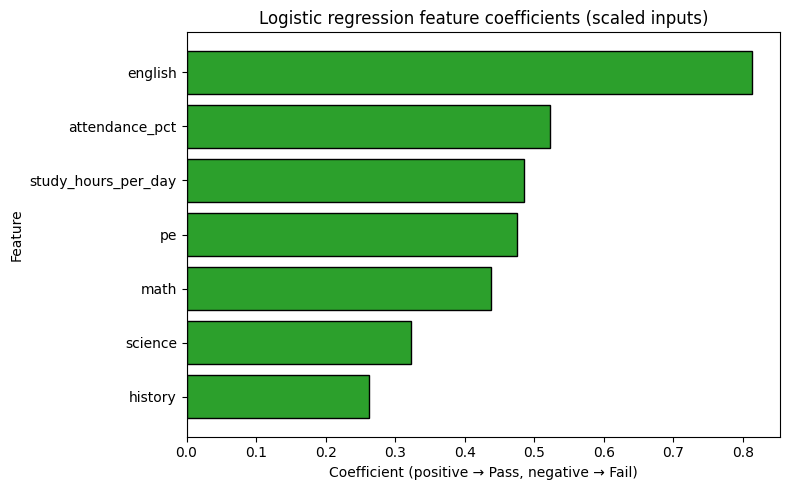


New student prediction: Pass
  P(Fail=0.0920), P(Pass=0.9080)


/Users/shekharchatterjee/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [5]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("students.csv")

feature_cols = [
    "math",
    "science",
    "english",
    "history",
    "pe",
    "attendance_pct",
    "study_hours_per_day",
]
X = df[feature_cols]
y = df["passed"]

# Step 1 — Prepare data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2 — Train
model = LogisticRegression(max_iter=2000, random_state=42)
model.fit(X_train_scaled, y_train)
train_acc = model.score(X_train_scaled, y_train)
print(f"Training accuracy: {train_acc:.4f}")

# Step 3 — Evaluate
y_pred = model.predict(X_test_scaled)
test_acc = model.score(X_test_scaled, y_test)
print(f"Test accuracy: {test_acc:.4f}\n")

print("Per-student test results:")
for idx, pred in zip(X_test.index, y_pred):
    name = df.loc[idx, "name"]
    actual = int(y.loc[idx])
    pred_int = int(pred)
    ok = actual == pred_int
    mark = "correct" if ok else "wrong"
    print(f"  {name}: actual={actual}, predicted={pred_int} — {mark}")

# Step 4 — Feature importance (coefficients)
coefs = model.coef_[0]
pairs = list(zip(feature_cols, coefs))
pairs.sort(key=lambda t: abs(t[1]), reverse=True)
print("\nCoefficients (sorted by absolute value, largest first):")
for fname, c in pairs:
    print(f"  {fname}: {c:.4f}")

colors = ["tab:green" if c >= 0 else "tab:red" for _, c in pairs]
names_ord = [p[0] for p in pairs]
vals_ord = [p[1] for p in pairs]

fig_coef, ax_coef = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(names_ord))
ax_coef.barh(y_pos, vals_ord, color=colors, edgecolor="black")
ax_coef.set_yticks(y_pos)
ax_coef.set_yticklabels(names_ord)
ax_coef.invert_yaxis()
ax_coef.axvline(0, color="gray", linewidth=0.8)
ax_coef.set_xlabel("Coefficient (positive → Pass, negative → Fail)")
ax_coef.set_ylabel("Feature")
ax_coef.set_title("Logistic regression feature coefficients (scaled inputs)")
plt.tight_layout()
fig_coef.savefig("plot_logistic_coefs.png", dpi=150, bbox_inches="tight")
plt.show()

# Step 5 — Bonus: new student
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
new_scaled = scaler.transform(new_student)
new_pred = model.predict(new_scaled)[0]
new_proba = model.predict_proba(new_scaled)[0]
label = "Pass" if new_pred == 1 else "Fail"
print(f"\nNew student prediction: {label}")
print(f"  P(Fail={new_proba[0]:.4f}), P(Pass={new_proba[1]:.4f})")